In [1]:
import pathlib
import os
import itertools
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import pingouin as pg
import pickle

 
import STX3KO_analyses as stx
from STX3KO_analyses import utilities as u


plt.rcParams['pdf.fonttype']=42
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['font.serif'] = 'Arial'


%matplotlib inline

%load_ext autoreload
%autoreload 2

In [2]:
figdir = pathlib.Path('/mnt/BigDisk/fig_scratch/stx3/figS7_CA3_DG_placecells')
figdir.mkdir(exist_ok=True)

In [3]:
# CA3

mouse = 'CA3-1'
deets = {'date': '24_10_2021', 'scene': 'YMaze_LNovel', 'session': 1, 'scan': -1, 'novel_arm': -1, 'ravel_ind': -1}
pkldir = os.path.join('/home/mplitt/YMazeSessPkls/', mouse)
sess = stx.session.YMazeSession.from_file(
            os.path.join(pkldir, deets['date'], "%s_%d.pkl" % (deets['scene'], deets['session'])),
            verbose=False, novel_arm=deets['novel_arm'])

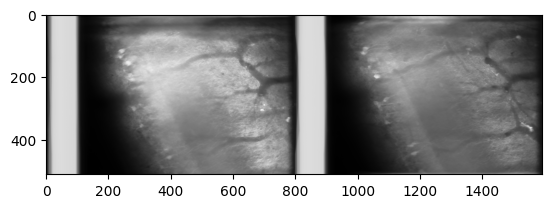

In [4]:
fig, ax = plt.subplots()
ax.imshow(sess.s2p_ops['meanImg'], cmap='Greys_r')

In [5]:
cells = [34, 58, 49, 75]

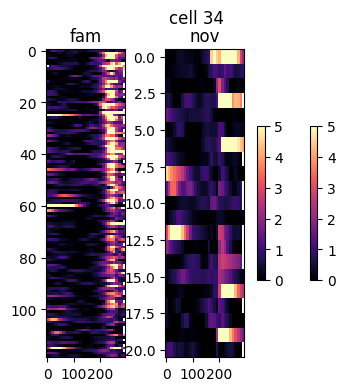

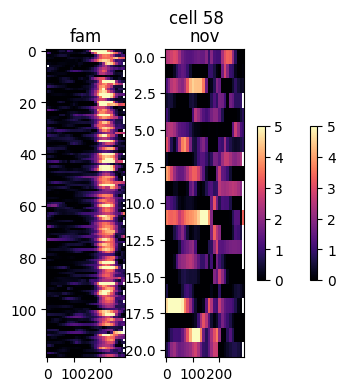

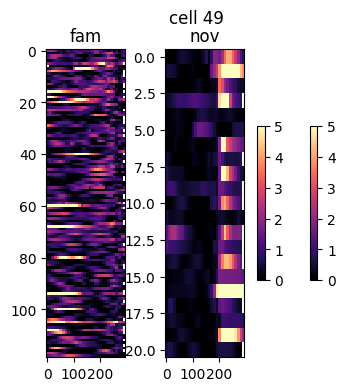

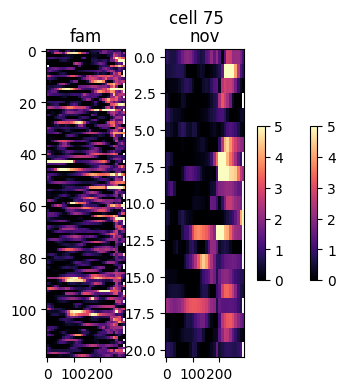

In [6]:
for cell in cells:

    fig, ax = plt.subplots(1,2, figsize=[4,4])
    fig.subplots_adjust(wspace=.5)

    for i, ttype in enumerate(('fam', 'nov')):
        if ttype == 'fam':
            trial_mask = sess.trial_info["LR"]!=sess.novel_arm
        else:
            trial_mask = sess.trial_info["LR"]==sess.novel_arm
        cell_mat = sess.trial_matrices['F_dff'][trial_mask,:, cell] 

        h = ax[i].imshow(cell_mat/np.nanmean(cell_mat.ravel()), cmap='magma', aspect='auto', vmin=0, vmax=5, interpolation='none')
        ax[i].set_title(ttype)
        ax[i].set_xticks([0,10,20], labels = [0, 100, 200])
        plt.colorbar(h, 
                    ax=ax,
                    shrink=0.5,
                    )
    fig.suptitle(f'cell {cell}')
    fig.savefig(figdir / f"CA3Examples_{mouse}_{deets['date']}_cell{cell}.pdf")
    


In [7]:
# example DG

mouse = 'Cre7'
deets = {'date': '28_10_2021', 'scene': 'YMaze_LNovel', 'session': 3, 'scan': -1, 'novel_arm': -1, 'ravel_ind': -1}
pkldir = os.path.join('/home/mplitt/YMazeSessPkls/', mouse)
sess = stx.session.YMazeSession.from_file(
            os.path.join(pkldir, deets['date'], "%s_%d.pkl" % (deets['scene'], deets['session'])),
            verbose=False, novel_arm=deets['novel_arm'])


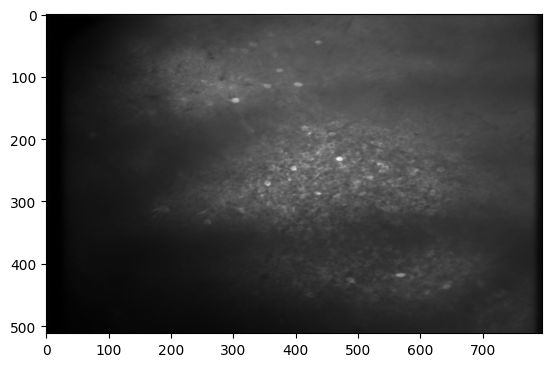

In [8]:
fig, ax = plt.subplots()
ax.imshow(sess.s2p_ops['meanImg'], cmap='Greys_r')

In [13]:
# cells = [1,9,16,14]
cells =[2,3,11,34,44]

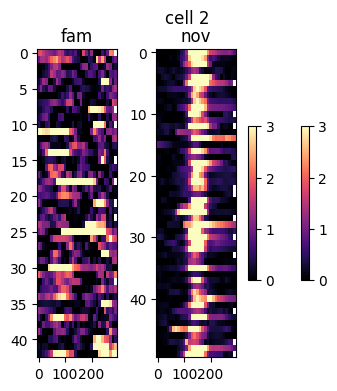

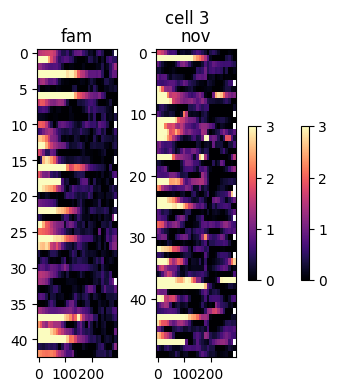

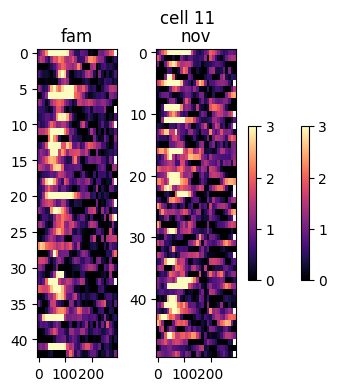

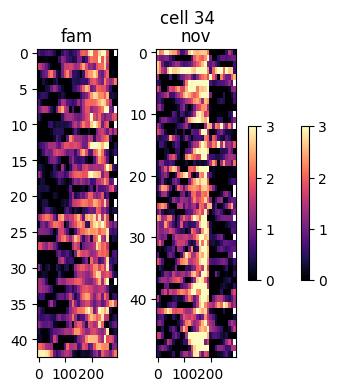

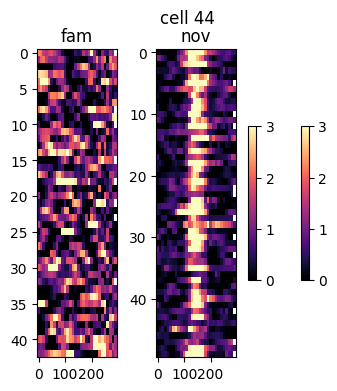

In [14]:
for cell in cells:

    fig, ax = plt.subplots(1,2, figsize=[4,4])
    fig.subplots_adjust(wspace=.5)

    for i, ttype in enumerate(('fam', 'nov')):
        if ttype == 'fam':
            trial_mask = sess.trial_info["LR"]!=sess.novel_arm
        else:
            trial_mask = sess.trial_info["LR"]==sess.novel_arm
        cell_mat = sess.trial_matrices['F_dff'][trial_mask,:, cell] 

        h = ax[i].imshow(cell_mat/np.nanmean(cell_mat.ravel()), cmap='magma', aspect='auto', vmin=0, 
                         vmax=3, interpolation='none')
        ax[i].set_title(ttype)
        ax[i].set_xticks([0,10,20], labels = [0, 100, 200])
        plt.colorbar(h, 
                    ax=ax,
                    shrink=0.5,
                    )
    fig.suptitle(f'cell {cell}')
    fig.savefig(figdir / f"DGExamples_{mouse}_{deets['date']}_cell{cell}.pdf")
    
